# In Silico Metrics

In [ ]:
import sys

sys.path.append("../../BayesFlow")
sys.path.append("../")

import os
if "KERAS_BACKEND" not in os.environ:
    # set this to "torch", "tensorflow", or "jax"
    os.environ["KERAS_BACKEND"] = "torch"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import bayesflow as bf
import keras
import pickle

from dmc import dmc_helpers, DMC


INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).


## Load Approximator

In [ ]:
network_name = 'initial_priors_sdr_estimated'

approximator = keras.saving.load_model('../training_checkpoints/' + network_name + '.keras')

/home/administrator/miniforge3/envs/bf_new/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 159 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# Load Model Specifications and define Simulator

In [ ]:

model_specs_path = '../model_specs/model_specs_' + network_name + '.pickle'
with open(model_specs_path, 'rb') as file:
    model_specs = pickle.load(file)

simulator = DMC(**model_specs['simulation_settings'])


## Simulate Data

In [ ]:
# simulate 500 data set with 300 observations each:
val_data = simulator.sample(500, num_obs=300, seed=123)


 300


## Posterior Samples

In [ ]:
post_samples = approximator.sample(conditions=val_data, num_samples=1000)

## Plot Diagnostics

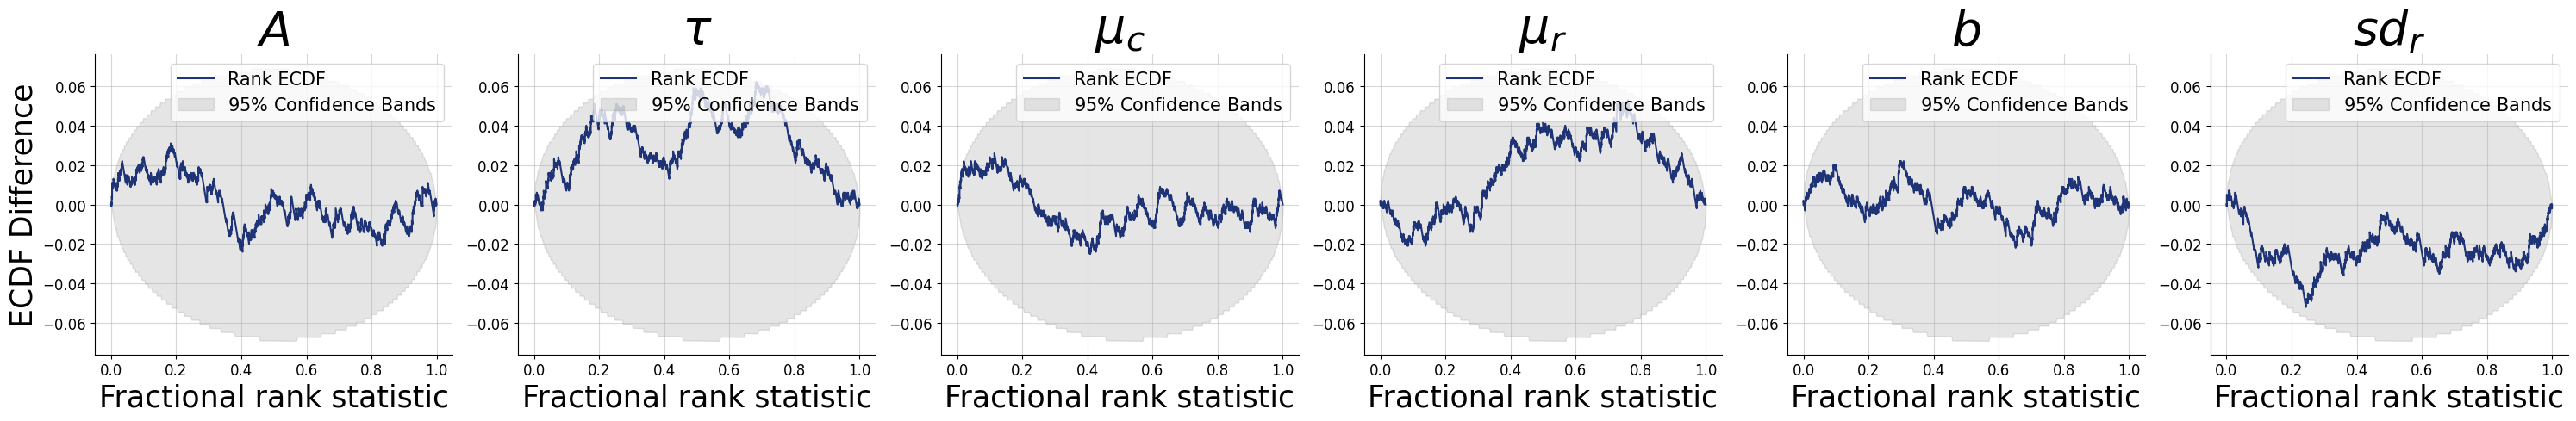

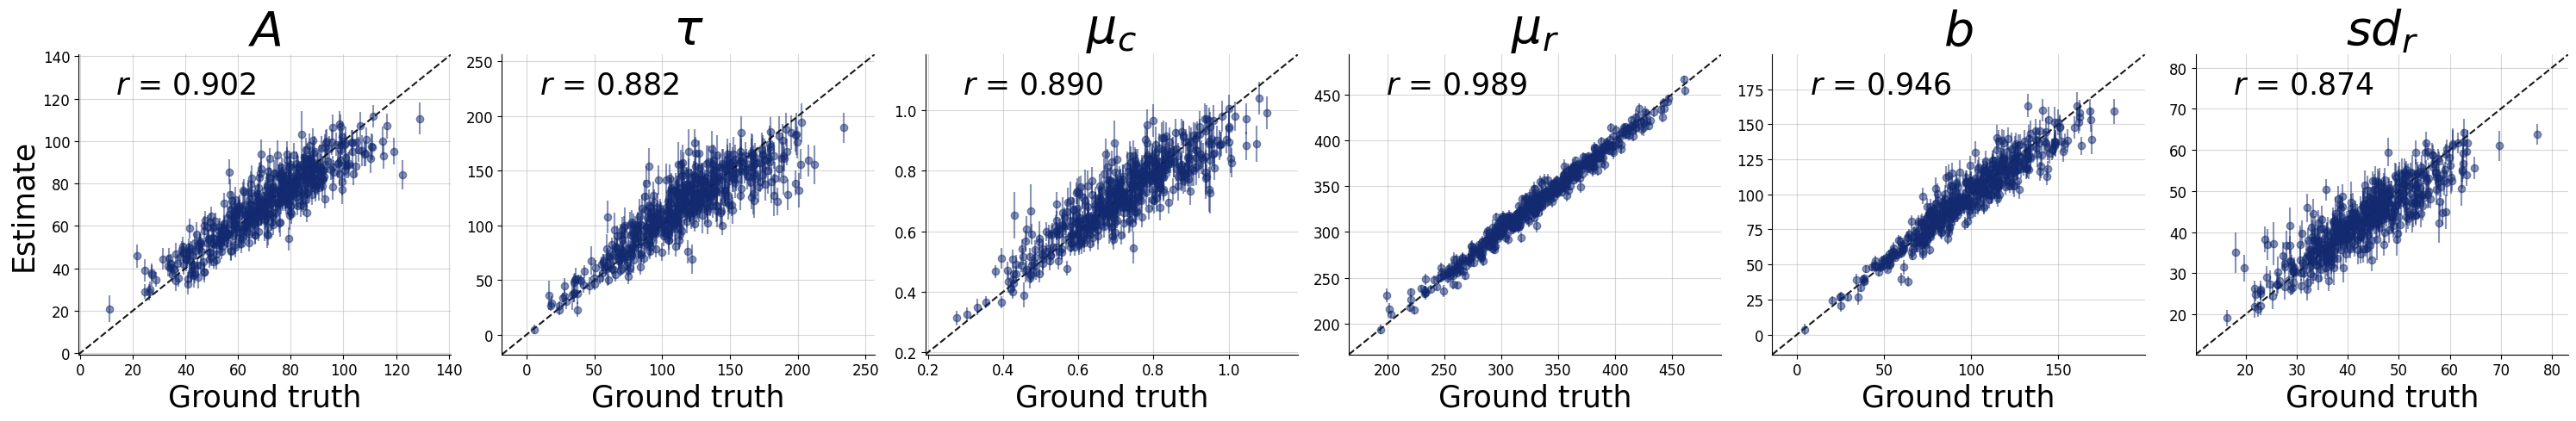

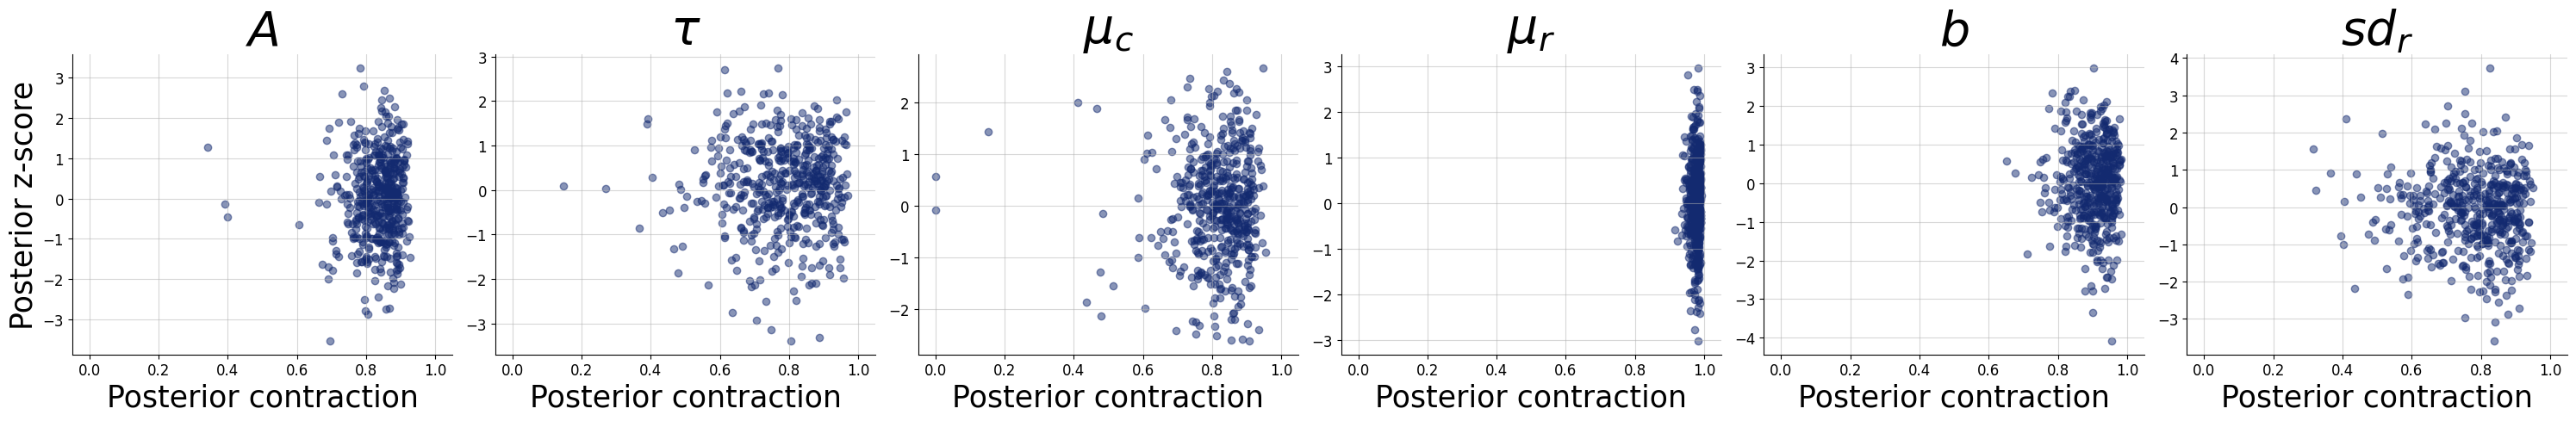

In [17]:
title_fontsize = 40
label_fontsize = 25
legend_fontsize = 15

fic_sbc = bf.diagnostics.calibration_ecdf(targets=val_data, 
                                          estimates=post_samples, 
                                          variable_names=dmc_helpers.param_labels(model_specs['simulation_settings']['param_names']), 
                                          difference=True, 
                                          title_fontsize=title_fontsize, 
                                          label_fontsize=label_fontsize, 
                                          legend_fontsize=legend_fontsize)

fig_rec = bf.diagnostics.recovery(targets=val_data, 
                                  estimates=post_samples, 
                                  metric_fontsize=25, 
                                  variable_names=dmc_helpers.param_labels(model_specs['simulation_settings']['param_names']), 
                                  title_fontsize=title_fontsize, label_fontsize=label_fontsize)

fig_pc = bf.diagnostics.z_score_contraction(targets=val_data, 
                                            estimates=post_samples, 
                                            variable_names=dmc_helpers.param_labels(model_specs['simulation_settings']['param_names']), 
                                            title_fontsize=title_fontsize, 
                                            label_fontsize=label_fontsize)